# Dane titanic

## Wczytanie danych

In [71]:
# wczytanie bibliotek
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path('data') # change to path folder with data

Zbiór danych titanic zawiera wybrane charakterystyki opisujące pasażerów Titanica (w tym m.in. takie zmienne jak: wiek, płeć, miejsce rozpoczęcia podróży czy klasa pasażerska) wraz z informacją czy dana osoba przeżyła katastrofę (zmienna Survived, która jest naszą zmienną predykowaną)


Poniżej tabela z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [72]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId') # wczytanie danych

In [73]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

## Podstawowe informacje o danych

In [74]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [75]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [76]:
titanic_df.shape

(891, 11)

W zbiorze znajduje się 891 obserwacji i 12 cech.

In [77]:
titanic_df.describe() # podstawowe wskaźniki statystyczne dla zmiennych numerycznych

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [78]:
titanic_df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare         98
Cabin       687
Embarked      2
dtype: int64

In [79]:
missing_percent = titanic_df.isnull().sum() / len(titanic_df) * 100
missing_percent

Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare        10.998878
Cabin       77.104377
Embarked     0.224467
dtype: float64

W zbiorze występują braki dla zmiennej Age, Fare, Cabin i Embarked. Najwięcej braków występuje dla Cabin.


In [80]:
print(titanic_df['Cabin'].describe())

count         204
unique        147
top       B96 B98
freq            4
Name: Cabin, dtype: object


In [81]:
print(titanic_df['Cabin'].value_counts().head(10))

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
F2             3
E101           3
D              3
C78            2
C93            2
Name: count, dtype: int64


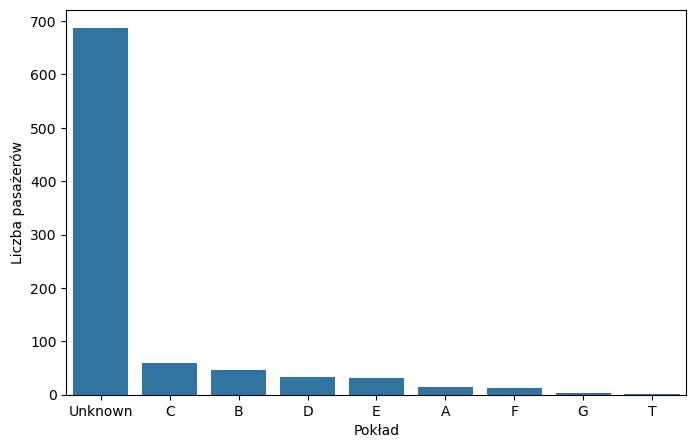

In [82]:
# wyciągnięcie litery pokładu (dla braków wstawiamy 'Unknown')
deck = titanic_df['Cabin'].fillna('Unknown').apply(lambda x: x[0] if x != 'Unknown' else 'Unknown')
plt.figure(figsize=(8, 5))
sns.countplot(x=deck, order=deck.value_counts().index)
plt.xlabel('Pokład')
plt.ylabel('Liczba pasażerów')
plt.show()

Zdecydowana większość pasażerów nie posiada informacji o kabinie, dlatego decydujemy się usunąć tę zmienną. Wśród pasażerów, dla których dostępna jest informacja o kabinie, dominowali pasażerowie podróżujący na pokładzie C i B, a najmniej osób podróżowało w G i T

## Przygotowanie danych

Ze zmiennej Name wyodrębniam nową kolumnę "Title" - tytuł danej osoby, nastepnie usuwam Name i Ticket, bo nie będą one przydatne w analizie. Kolumnę Cabin również usuwamy ze względu na dużą liczbę wartości brakujących. Zmienne Sex, Embarked zamieniamy na typ categorical, a Pclass na ordered
categorical.

In [83]:
# utworzenie kolumny Title
titanic_df["Title"] = titanic_df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
titanic_df["Title"] = titanic_df["Title"].replace(rare_titles, "Rare")
titanic_df["Title"] = titanic_df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
titanic_df["Title"].value_counts()

# usunięcie zmiennych
titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Cabin"])

# zmiana typów zmiennych
#titanic_df["Survived"] = titanic_df["Survived"].astype("category")
titanic_df["Sex"] = titanic_df["Sex"].astype("category")
titanic_df["Embarked"] = titanic_df["Embarked"].astype("category")
titanic_df["Pclass"] = pd.Categorical(titanic_df["Pclass"], categories=[1, 2, 3], ordered=True)

Poniżej widzimy typy zmiennych po konwersji

In [84]:
titanic_df.dtypes

Survived       int64
Pclass      category
Sex         category
Age          float64
SibSp          int64
Parch          int64
Fare         float64
Embarked    category
Title         object
dtype: object

Poniżej sprawdźmy rozkłady zmiennych przed imputacją


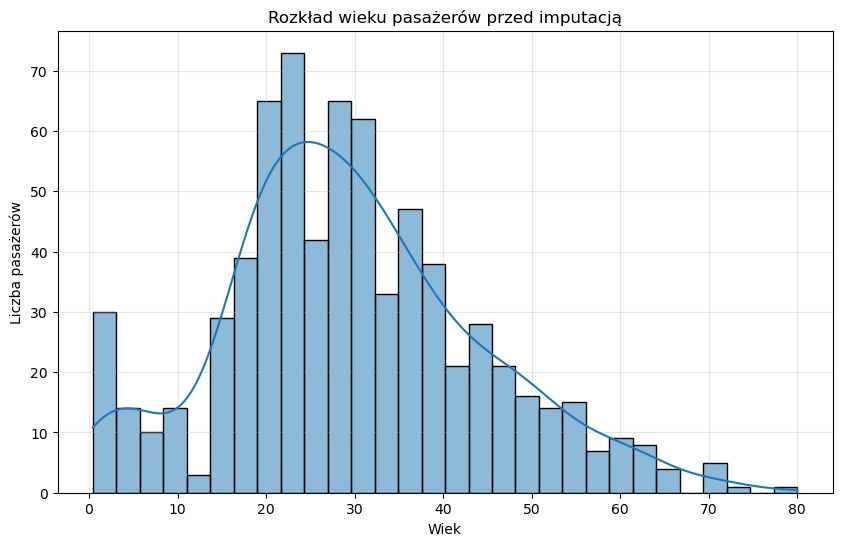

In [85]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=titanic_df,
    x="Age",
    bins=30,
    kde=True
)

plt.xlabel("Wiek")
plt.ylabel("Liczba pasażerów")
plt.title("Rozkład wieku pasażerów przed imputacją")
plt.grid(alpha=0.3)
plt.show()

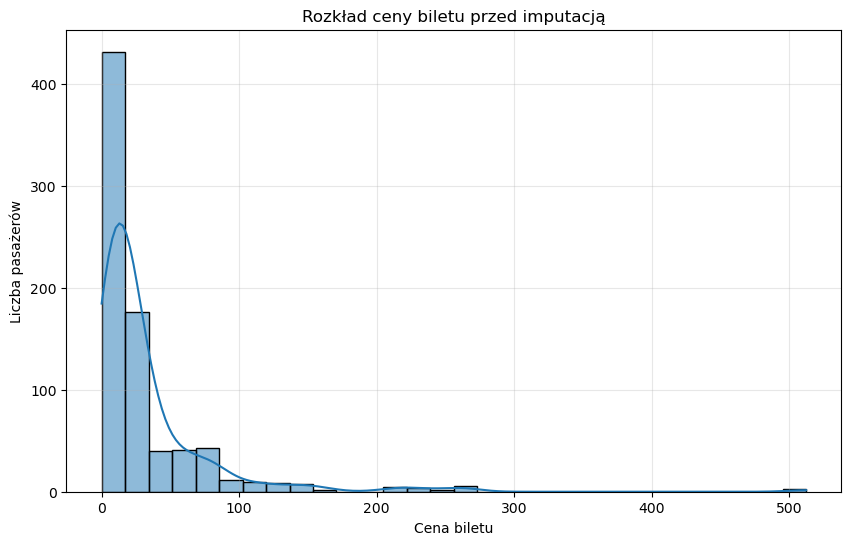

In [86]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=titanic_df,
    x="Fare",
    bins=30,
    kde=True
)

plt.xlabel("Cena biletu")
plt.ylabel("Liczba pasażerów")
plt.title("Rozkład ceny biletu przed imputacją")
plt.grid(alpha=0.3)
plt.show()

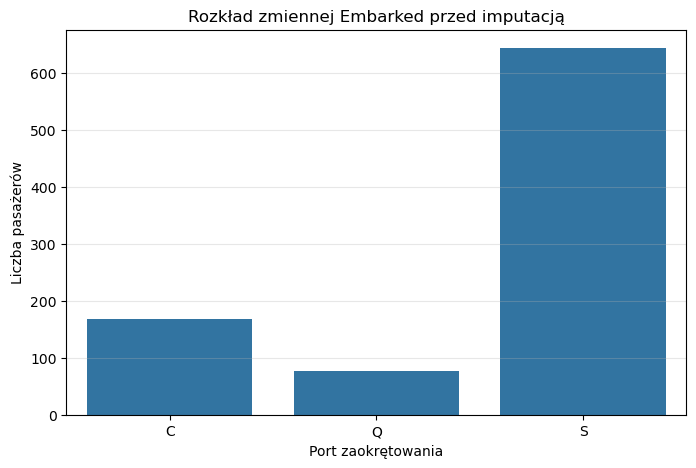

In [87]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=titanic_df,
    x="Embarked"
)

plt.xlabel("Port zaokrętowania")
plt.ylabel("Liczba pasażerów")
plt.title("Rozkład zmiennej Embarked przed imputacją")
plt.grid(axis="y", alpha=0.3)
plt.show()

Wartości brakujące dla zmiennej Age i Fare zastępujemy medianą, zaś braki dla zmiennej Embarked wystąpiły tylko dla dwóch obserwacji, zastępujemy je dominantą.

In [88]:
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Fare"] = titanic_df["Fare"].fillna(titanic_df["Fare"].median())

In [89]:
titanic_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
dtype: int64

In [90]:
# dodajemy nowe zmienne, które mogą być przydatne w analizie
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1 # liczba członków rodziny na pokładzie
titanic_df["IsChild"] = titanic_df["Age"] < 18 # czy pasażer jest dzieckiem
titanic_df["IsChild"] = titanic_df["IsChild"].astype("category")
titanic_df.dtypes

Survived         int64
Pclass        category
Sex           category
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked      category
Title           object
FamilySize       int64
IsChild       category
dtype: object

In [91]:
numeric_cols = titanic_df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Survived')
categorical_cols = titanic_df.select_dtypes(include=['object', 'category']).columns

In [92]:
for column in categorical_cols:
    print(titanic_df[column].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64
IsChild
False    778
True     113
Name: count, dtype: int64


Nie zauważamy jakichś nietypowych, rzadko występujących kategorii.

## Wizualizacja zmiennych

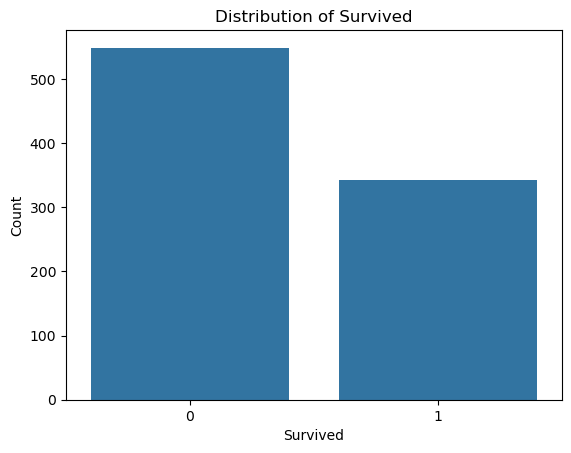

In [93]:
sns.countplot(x='Survived', data=titanic_df)
plt.title('Distribution of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

Większość pasażerów nie przeżyła katastrofy. Zginęło około 550 osób, zaś przeżyło około 350.

### Histogramy dla zmiennych numerycznych

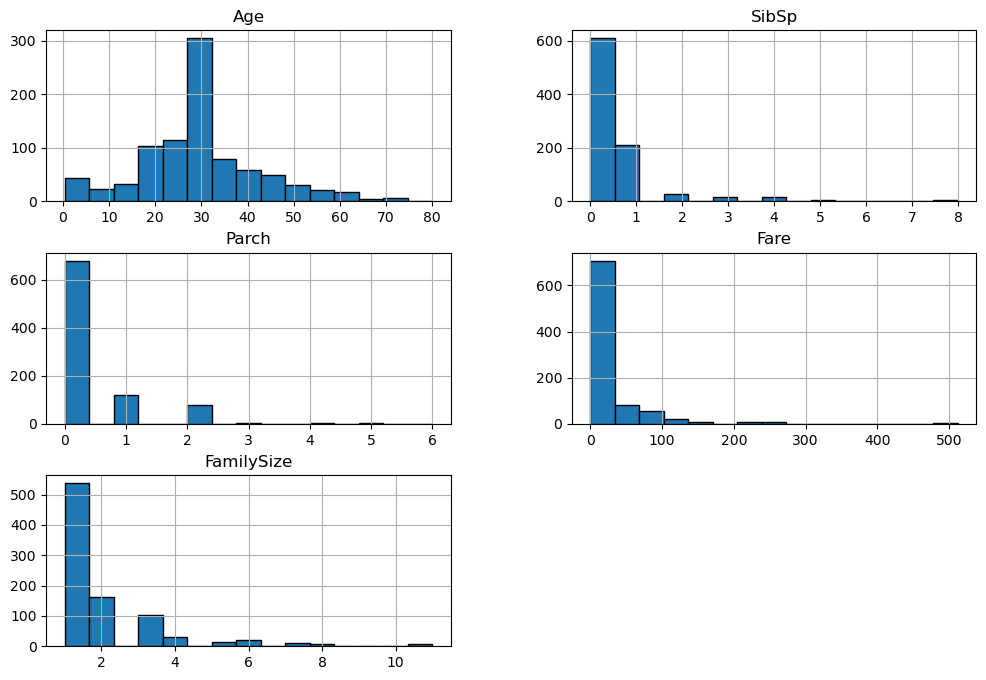

In [94]:
titanic_df[numeric_cols].hist(figsize=(12, 8), bins=15, edgecolor='black')
plt.show()

**Age**: Najwięcej pasażerów plasuje się w przedziale 20-30 lat, jednak szczyt w okolicach 30 jest skutkiem naszego uzupełnienia braków medianą.

**SibSp**: Zdecydowana większość pasażerów (ponad 600 osób) podróżowała bez rodzeństwa ani małżonka (0). Około 200 osób podróżowało z jedną osobą, a wyższe wartości występują bardzo rzadko.

**Parch**: Zdecydowana większość pasażerów podróżowała bez rodziców i dzieci. Wartości 1 i 2 występują sporadycznie, a ponad 2 bardzo rzadko.

**Fare**: Większość biletów została zakupiona w niskich cenach, wysokie wartości występują rzadko.

**FamilySize**: Większość pasażerów podróżowała samodzielnie (FamilySize równe 1), wyższe wartości występuje znacznie rzadziej.

Zmienne SibSp, Parch, Fare, FamilySize mają rozkład prawostronnie skośny.

### Wykresy słupkowe dla zmiennych kategorycznych

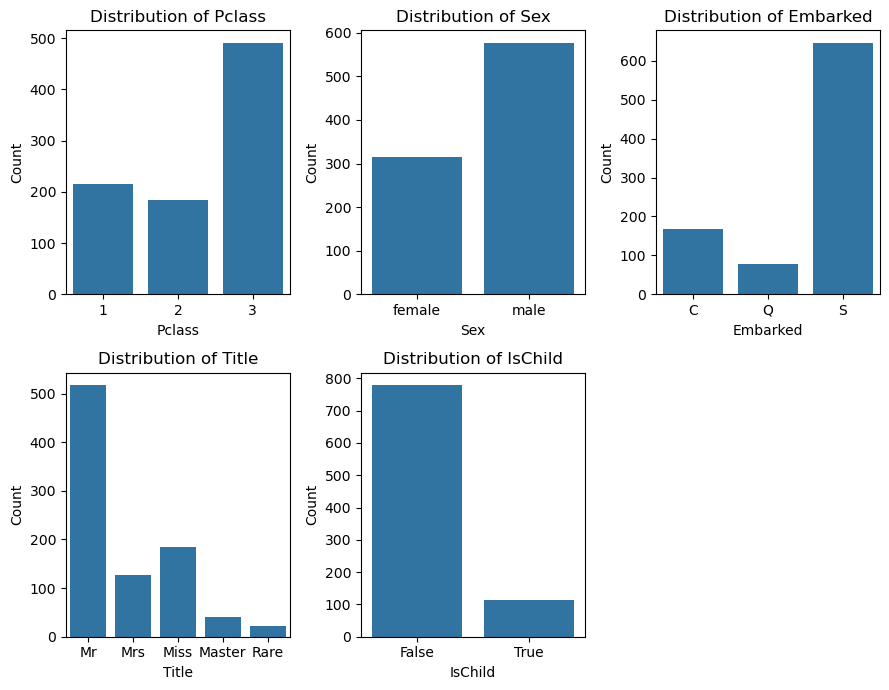

In [95]:
plt.figure(figsize=(9, 7))

for idx, column in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, idx)
    sns.countplot(x=column, data=titanic_df)
    plt.title(f'Distribution of {column}')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


**Pclass**: Większość pasażerów podróżowała w 3 klasie (prawie 500), a pozostałe klasy (1 i 2) miały zbliżoną do siebie ilość pasażerów (około 200).

**Sex**: Większość podróżnych to byli mężczyźni (ok. 580), a kobiet było tylko nieco ponad 300.

**Embarked**: Zdecydowana większość pasażerów wsiadła w Southampton (ponad 600 osób). W Cherbourgu (C) wsiadło około 170 osób, a najmniej w Queenstown (Q) - poniżej 100 osób.

**Title**: Większość pasażerów miała tytuł Mr, czyli byli to dorośli mężczyźni.

**IsChild**: Większość pasażerów była dorosła (prawie 800 osób), dzieci stanowiły niewielką część podróżujących (około 100 osób).


## Survived a pozostałe zmienne

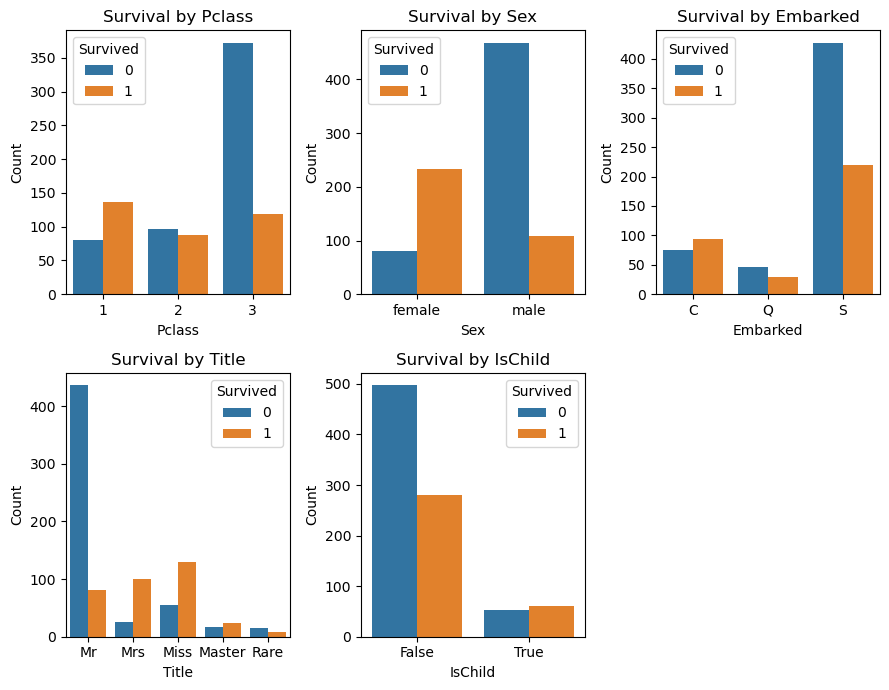

In [96]:
plt.figure(figsize=(9, 7))
for idx, column in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, idx)
    sns.countplot(data=titanic_df, x=column, hue='Survived')
    plt.title(f'Survival by {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Sex**: kobiety znacznie częściej przeżywały katastrofę niż mężczyźni. Większość kobiet przeżyła, zaś u mężczyzn odwrotnie - większość zginęła.

**Pclass**: wyższa klasa wiązała się z większą szansą na przeżycie. W klasie 3 zdecydowana większość pasażerów zginęła, w drugiej jest to dość wyrównane, a w klasie 1 większość przeżyła.

**Embarked**: większosć pasażerów, którzy wsiedli w Southampton oraz Queenstown, zginęła w katastrofie. W przypadku osób, które wsiadły w Cherbourgu, liczba osób, które przeżyły, jest większa w stosunku do tych, które zginęły.

**Title**: w katastrofie zginęli głównie dorośli mężczyźni (Mr), mają oni niski wskaźnik przeżycia, podczas gdy kobiety (Mrs, Miss) oraz chłopcy (Master) mieli wysoki wskaźnik przeżycia

**IsChild**: wśród dorosłych zdecydowana większość zginęła w katastrofie. U dzieci występuje nieznaczna przewaga osób, które przeżyły.


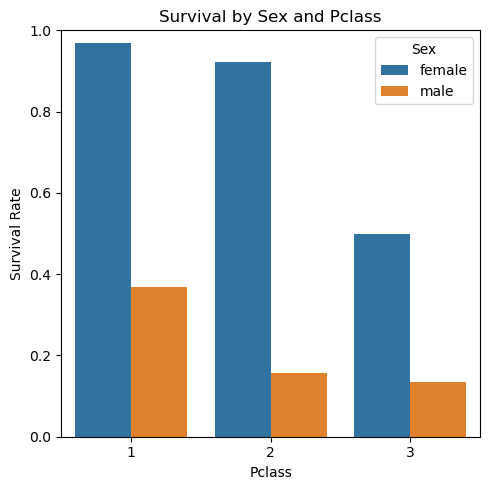

In [97]:
survival_by_sex_class = (titanic_df.groupby(['Pclass', 'Sex'], observed=True)['Survived'].mean().reset_index())

plt.figure(figsize=(5,5))
sns.barplot(data=survival_by_sex_class, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival by Sex and Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Kobiety przeżywały znacznie częściej niż mężczyźni niezależnie od klasy biletu. Wraz ze wzrostem wartości Pclass przeżywalność była niższa. Zatem płeć oraz klasa biletu były czynnikami, które były mocno związane z przeżywalnością. Największą szansę na przeżycie miały kobiety z klasy 1.

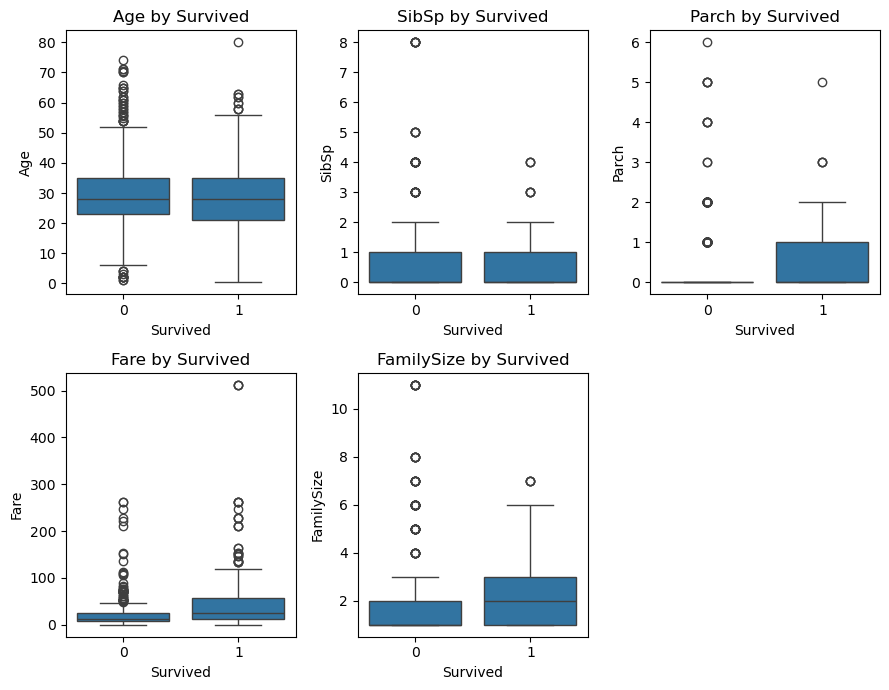

In [98]:
plt.figure(figsize=(9,7))

for idx, column in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, idx)
    sns.boxplot(data=titanic_df, x='Survived', y=column)
    plt.title(f'{column} by Survived')
    plt.xlabel('Survived')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

Na podstawie boxplotów możemy zauważyć, że w zbiorze występują wartości odstające. Mimo to, zakresy zmiennych wydają się być normalne. Większość z outlierów wydaje się być naturalnym zjawiskiem, dlatego ich nie usuwamy.


## Kodowanie zmiennych kategorycznych

In [99]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df['IsChild'] = titanic_df['IsChild'].astype(int)
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True, dtype=int) #one-hot encoding dla zmiennej Embarked
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Title,FamilySize,IsChild,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,Mr,2,0,0,1
2,1,1,1,38.0,1,0,71.2833,Mrs,2,0,0,0
3,1,3,1,26.0,0,0,7.9250,Miss,1,0,0,1
4,1,1,1,35.0,1,0,53.1000,Mrs,2,0,0,1
5,0,3,0,35.0,0,0,8.0500,Mr,1,0,0,1


## Macierz korelacji

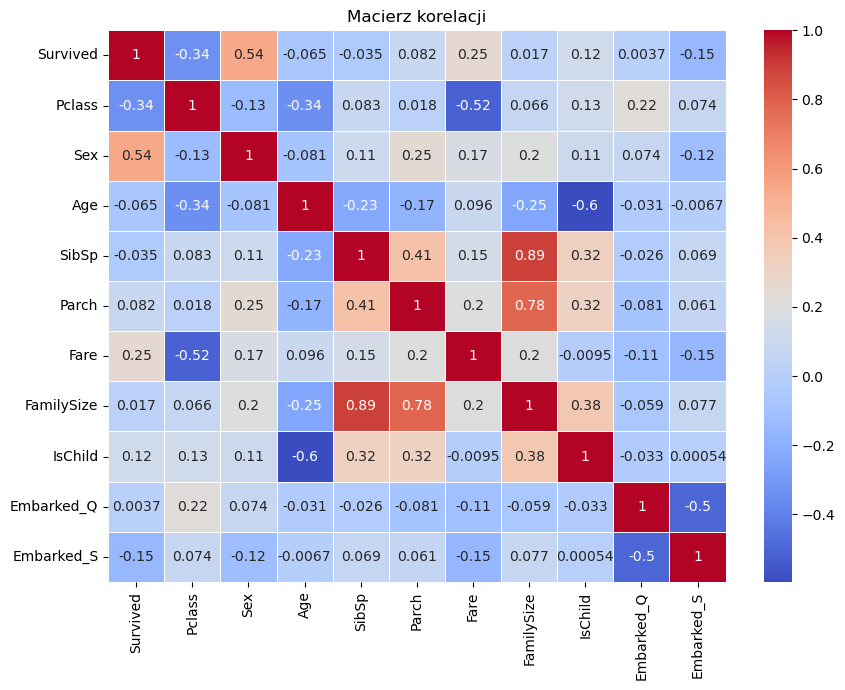

In [100]:
corr = titanic_df.drop(columns=["Title"]).corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()

Zmienna **Survived** jest ujemnie skorelowana z **Pclass**, co oznacza zależność między klasą biletu a przeżywalnością. Podróżujący klasą o wyższym numerze (3) mieli mniejszą przeżywalność, niż ci z klasy 1 czy 2. Występuje również dodatnia korelacja **Survived** z **Fare**, czyli osoby z droższymi biletami częściej przeżywały katastrofę. Nie ma praktycznie żadnej korelacji między **Survived** a liczbą osób z rodziny, z którymi pasażer podróżował.

## Wnioski
Na podstawie analizy możemy zauważyć, że płeć była jednym z czynników wpływających na przeżywalność pasażerów. Kobiety znacznie częściej przeżywały katastrofę niż mężczyźni. Kolejną analizowaną cechą jest klasa biletu pasażera. Osoby podróżujące w wyższych klasach, tzn. przy niższej wartości Pclass (która wiąże się również z wyższą ceną biletu) charakteryzowały się znacznie większą przeżywalnością. Najniższą przeżywalność obserwujemy w klasie 3, a największą w klasie 1.

In [101]:
titanic_df.info()
titanic_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    category
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   Title       891 non-null    object  
 8   FamilySize  891 non-null    int64   
 9   IsChild     891 non-null    int32   
 10  Embarked_Q  891 non-null    int32   
 11  Embarked_S  891 non-null    int32   
dtypes: category(2), float64(2), int32(3), int64(4), object(1)
memory usage: 68.1+ KB


Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Title         0
FamilySize    0
IsChild       0
Embarked_Q    0
Embarked_S    0
dtype: int64